## Complete ARES Cost Comparison Summary

# DCE Demo with Enhanced Save and Metrics

In [1]:
import pandas as pd
import numpy as np
import torch
import math
import os
from datetime import datetime

from explainers.model import Model
from explainers.DCEHeuristic import DCENonDifferentiable

from data_loader.cardio import CardioData
from data_loader.german_credit import GermanCreditData
from data_loader.hotel_booking import HotelBookingData
from data_loader.heloc import HelocData
from data_loader.compas import CompasData

# Method selection
method = "non_differentiable"  # Options: "gradient", "non_differentiable"

# Strategy selection (only used when method="non_differentiable")
strategy_type = "genetic"  # Options: "monte_carlo", "genetic", "simulated_annealing", "bayesian", "differential_evolution"

# Cone sampling control switches (only used when method="non_differentiable")
use_cone_sampling_categorical = True   # True = cone sampling, False = original random sampling
use_cone_sampling_continuous = True    # True = cone sampling, False = original random sampling

# Import strategies based on method selection
if method == "gradient":
    from explainers.DCEgradient import DCEExplainerGradient
elif method == "non_differentiable":
    # Import strategies from cone_sampling (now supports both modes via switches)
    from explainers.cone_sampling.genetic import GeneticStrategy
    from explainers.cone_sampling.monte_carlo import MonteCarloStrategy
    from explainers.cone_sampling.simulated_annealing import SimulatedAnnealingStrategy
    from explainers.cone_sampling.bayesian import BayesianStrategy
    from explainers.cone_sampling.differential_evolution import DifferentialEvolutionStrategy
else:
    raise ValueError(f"Unknown method: {method}")

pd.set_option('display.max_columns', None)

print("🚀 DCE Demo with Method and Strategy Selection")
print(f"📅 Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🎯 Selected method: {method}")

if method == "non_differentiable":
    print(f"🎲 Selected strategy: {strategy_type}")
    print(f"🔧 Categorical cone sampling: {'ON' if use_cone_sampling_categorical else 'OFF (original mode)'}")
    print(f"🔧 Continuous cone sampling: {'ON' if use_cone_sampling_continuous else 'OFF (original mode)'}")

🚀 DCE Demo with Method and Strategy Selection
📅 Timestamp: 2025-08-21 18:15:03
🎯 Selected method: non_differentiable
🎲 Selected strategy: genetic
🔧 Categorical cone sampling: ON
🔧 Continuous cone sampling: ON


In [2]:
# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print(f"🎲 Random seed set to: {seed}")

🎲 Random seed set to: 42


## Dataset Selection

In [3]:
# Choose your dataset

# data = CardioData(seed=seed)
# dataset_name = "cardio"

data = GermanCreditData(seed=seed)
dataset_name = "german_credit"

# data = HelocData(seed=seed)
# dataset_name = "Heloc"

# data = CompasData(seed=seed)
# dataset_name = "compas"

# data = HotelBookingData(seed=seed)
# dataset_name = "hotel_booking"

print(f"📊 Dataset loaded: {dataset_name}")

📊 Dataset loaded: german_credit


In [4]:
# Get data for explanation - Multiple sampling methods
# Configuration for sampling method
sampling_config = {
    "method": "model_y_zero",  # Options: "standard", "risk_filter", "fixed_indices", "model_y_zero"
    "sample_num": 50,
    "risk_filter": None,  # 0 for low risk, 1 for high risk (only used when method="risk_filter")
    "fixed_indices": None,  # List of specific indices (only used when method="fixed_indices")
    "model_y_zero_count": 50  # Number of samples where model prediction = 0 (only used when method="model_y_zero")
}

def get_explanation_samples(data, sampling_config, model=None, seed=42):
    """Get samples for explanation based on configuration."""
    method = sampling_config["method"]
    sample_num = sampling_config["sample_num"]
    
    print(f"📊 Sampling method: {method}")
    
    if method == "standard":
        # Standard random sampling (same as original demo)
        df_explain = data.get_df_explain(sample_num=sample_num)
        print(f"   Standard random sampling: {len(df_explain)} samples")
        
    elif method == "risk_filter":
        # Filter by risk level (same as server_experiment_config_multi)
        risk_filter = sampling_config.get("risk_filter")
        if risk_filter is None:
            raise ValueError("risk_filter must be specified when method='risk_filter'")
        
        # Get raw data and filter by risk
        df_raw = data.df[data.df["Risk"] == risk_filter].head(sample_num)
        if len(df_raw) < sample_num:
            print(f"   Warning: Only {len(df_raw)} samples available with Risk={risk_filter}, requested {sample_num}")
        
        # Standardize the filtered data
        df_explain = (df_raw[data.features] - data.mean) / data.std
        data.df_explain = df_explain  # Set for compatibility
        print(f"   Risk filter (Risk={risk_filter}): {len(df_explain)} samples")
        
    elif method == "fixed_indices":
        # Use fixed indices (same as server_experiment_config_multi)
        fixed_indices = sampling_config.get("fixed_indices")
        if fixed_indices is None or len(fixed_indices) == 0:
            raise ValueError("fixed_indices must be specified when method='fixed_indices'")
        
        # Get test data for indexing
        X_train, X_test, y_train, y_test = data.get_train_test()
        
        # Validate indices
        max_index = len(X_test) - 1
        valid_indices = [idx for idx in fixed_indices if 0 <= idx <= max_index]
        
        if len(valid_indices) < len(fixed_indices):
            print(f"   Warning: {len(fixed_indices) - len(valid_indices)} indices out of range (max: {max_index})")
        
        if len(valid_indices) == 0:
            raise ValueError("No valid indices found in fixed_indices")
        
        # Take only the required number of samples
        selected_indices = valid_indices[:sample_num]
        df_explain = X_test.iloc[selected_indices]
        data.df_explain = df_explain  # Set for compatibility
        print(f"   Fixed indices: {len(df_explain)} samples from indices {selected_indices[:5]}{'...' if len(selected_indices) > 5 else ''}")
        
    elif method == "model_y_zero":
        # New method: Select samples where model prediction = 0
        if model is None:
            raise ValueError("model must be provided when method='model_y_zero'")
        
        model_y_zero_count = sampling_config.get("model_y_zero_count", sample_num)
        
        # Get test data
        X_train, X_test, y_train, y_test = data.get_train_test()
        
        # Get model predictions on test set
        if model.backend == "pytorch":
            import torch
            with torch.no_grad():
                data_tensor = torch.FloatTensor(X_test.values)
                predictions = model.model(data_tensor).cpu().numpy().flatten()
        elif model.backend in ["sklearn", "lightgbm", "xgboost"]:
            try:
                prob_predictions = model.model.predict_proba(X_test.values)
                predictions = prob_predictions[:, 1]  # Probability for class 1
            except AttributeError:
                predictions = model.model.predict(X_test.values)
        else:
            raise ValueError(f"Unknown model backend: {model.backend}")
        
        # Find indices where prediction is close to 0 (< 0.5 for probability, exactly 0 for binary)
        if model.backend == "pytorch" or hasattr(model.model, 'predict_proba'):
            zero_indices = np.where(predictions < 0.5)[0]  # Probability < 0.5 means predicted class 0
        else:
            zero_indices = np.where(predictions == 0)[0]  # Binary prediction = 0
        
        print(f"   Found {len(zero_indices)} samples with model prediction = 0")
        
        if len(zero_indices) < model_y_zero_count:
            print(f"   Warning: Only {len(zero_indices)} samples available with y=0, requested {model_y_zero_count}")
            selected_count = len(zero_indices)
        else:
            selected_count = model_y_zero_count
        
        # Randomly sample from zero prediction indices
        np.random.seed(seed)
        selected_zero_indices = np.random.choice(zero_indices, size=selected_count, replace=False)
        
        df_explain = X_test.iloc[selected_zero_indices]
        data.df_explain = df_explain  # Set for compatibility
        print(f"   Model y=0 sampling: {len(df_explain)} samples where model predicts class 0")
        print(f"   Selected indices: {selected_zero_indices[:5]}{'...' if len(selected_zero_indices) > 5 else ''}")
        
    else:
        raise ValueError(f"Unknown sampling method: {method}")
    
    return df_explain

# Generate explanation samples based on configuration
# Note: For "model_y_zero" method, we need to wait until after model training
if sampling_config["method"] != "model_y_zero":
    df_explain = get_explanation_samples(data, sampling_config, seed=seed)
else:
    print("📊 Deferring sample selection for 'model_y_zero' method until after model training")
    df_explain = None  # Will be set after model training

# Display configuration
print(f"📋 Sampling Configuration:")
print(f"   Method: {sampling_config['method']}")
print(f"   Sample number: {sampling_config['sample_num']}")
if sampling_config['method'] == 'risk_filter':
    print(f"   Risk filter: {sampling_config['risk_filter']}")
elif sampling_config['method'] == 'fixed_indices':
    if sampling_config['fixed_indices']:
        indices_preview = sampling_config['fixed_indices'][:5] if len(sampling_config['fixed_indices']) > 5 else sampling_config['fixed_indices']
        print(f"   Fixed indices: {indices_preview}{'...' if len(sampling_config['fixed_indices']) > 5 else ''}")
    else:
        print(f"   Fixed indices: None (will cause error)")
elif sampling_config['method'] == 'model_y_zero':
    print(f"   Model y=0 count: {sampling_config['model_y_zero_count']}")

if df_explain is not None:
    print(f"✅ Explanation data ready: {len(df_explain)} samples")
else:
    print(f"⏳ Explanation data will be generated after model training")

📊 Deferring sample selection for 'model_y_zero' method until after model training
📋 Sampling Configuration:
   Method: model_y_zero
   Sample number: 50
   Model y=0 count: 50
⏳ Explanation data will be generated after model training


In [5]:
X_train, X_test, y_train, y_test = data.get_train_test()

# print(f"✅ Explanation data: {len(df_explain)} samples")
print(f"✅ Training data: {len(X_train)} samples")
print(f"✅ Test data: {len(X_test)} samples")

✅ Training data: 800 samples
✅ Test data: 200 samples


In [6]:
# # Manual sample selection using fixed indices (consistent with baseline)
# sample_num = 100

# # Fixed indices for test purpose (same as baseline_experiments_heloc.ipynb)
# # indice = [1825, 1735,  678,  351, 1791,  610,   70, 1124,   56,  900,  555,
# #              746, 1704,  462, 1873,  289,  593,  824,  530, 1424, 1063,  486,
# #              892,  554,  777, 1234, 1216,  374,  439, 1271,  651,  211,  886,
# #             1329, 1005, 1102, 1052,  111,  344,  305, 1376,  931, 1041, 1010,
# #             1640,  316,  432,  353,  426,  394, 1360, 1131,   99,  859, 1270,
# #              237, 1465,  710, 1653,  538,  382, 1830, 1632, 1314, 1781, 1494,
# #             1831, 1721,   69, 1788, 1546, 1753, 1931,  429, 1436, 1755,  251,
# #              756,  855,  128,  637,  864, 1809, 1402,  361, 1578, 1091, 1810,
# #             1615, 1138,  247,  845, 1628, 1239,  196, 1033,  584,  548,  722,
# #             1840]

# indice = [ 753,  582,  548,  113,  174,  420,  309,  998,  413, 1054, 1171,
#              275,  771, 1135,  415,  478,  609,  168,  332,  933,  490,  906,
#             1073,  128,  107, 1136,   43, 1168,  327,  610,  596,  631, 1205,
#              534,  597,  220,  911,  198,  743,  985,  231,  865, 1088,  715,
#              306,  101,  438,   78, 1223,   49,  936,  736,  243,  868, 1096,
#              937,  381,  767,   63,  323,   44,  943, 1098,  482,  575,  254,
#              529,  286,  992,  123,   76,  218, 1110,  545,  292,  701, 1226,
#              844,  363,  811,  754,  266,  904,  958,  590, 1222,  233,   70,
#              566,   23,  155,  707,   58,  428, 1008, 1057,  342,  629,   81,
#             1127]

# # Use all 100 samples from the fixed indices (same as baseline)
# selected_indices = indice  # Use all 100 indices

# # Convert X_test to match baseline format (similar to baseline processing)
# # Create a DataFrame with the same structure as baseline
# X_test_for_indexing = pd.DataFrame(X_test.values, columns=X_test.columns)
# # Reset index to match the original dataset indexing used in baseline
# X_test_for_indexing.index = range(len(X_test_for_indexing))

# # Check if indices are valid for our X_test
# max_available_index = len(X_test_for_indexing) - 1
# valid_indices = [idx for idx in selected_indices if idx <= max_available_index]

# if len(valid_indices) < len(selected_indices):
#     print(f"⚠️  Warning: Some indices exceed X_test size ({max_available_index})")
#     print(f"📊 Using {len(valid_indices)} valid indices out of {len(selected_indices)}")
#     selected_indices = valid_indices[:sample_num]  # Take up to sample_num valid indices
# else:
#     print(f"✅ All indices are valid for X_test size ({len(X_test_for_indexing)})")

# # Get the explanation data using valid indices
# df_explain = X_test_for_indexing.loc[selected_indices]

# # IMPORTANT: Set df_explain in the data object for HelocData compatibility
# data.df_explain = df_explain
# data.sample_num = len(df_explain)  # Update sample_num to match actual selection

# print(f"✅ Manual sample selection completed")
# print(f"📊 Selected {len(df_explain)} samples using fixed indices")
# print(f"🎯 Using {len(selected_indices)} indices from baseline")
# print(f"📈 Data shape: {df_explain.shape}")
# print(f"🔍 Sample indices: {selected_indices[:10]}... (showing first 10)")
# print(f"🔗 Set data.df_explain for HelocData compatibility")

## Model Selection

In [7]:
# # === SVM ===
# import os
# from models.svm import LinearSVM
# import torch
# import torch.nn as nn
# import torch.optim as optim

# # Convert to PyTorch tensors
# X_train_tensor = torch.FloatTensor(X_train.values)
# y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
# X_test_tensor = torch.FloatTensor(X_test.values)
# y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)
# # Initialize the model, loss function, and optimizer
# # model = BlackBoxModel(input_dim=X_train.shape[1])
# # model = RBFNet(input_dim=X_train.shape[1], hidden_dim=X_train.shape[1])
# model = LinearSVM(input_dim=X_train.shape[1])

# criterion = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=0.01)

# # Training loop
# num_epochs = 300
# for epoch in range(num_epochs):
#     # Forward pass
#     outputs = model(X_train_tensor)
#     loss = criterion(outputs, y_train_tensor)
    
#     # Backward pass and optimization
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

# # Evaluate on test set
# model.eval()
# with torch.no_grad():
#     test_outputs = model(X_test_tensor)
#     test_loss = criterion(test_outputs, y_test_tensor)

#     # Convert outputs to binary using 0.5 as threshold
#     y_pred_tensor = (test_outputs > 0.5).float()
#     correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
#     accuracy = correct_predictions / y_test_tensor.shape[0]
    
# model = Model(model=model, backend="pytorch", data=data)
# model_name = "SVM"

# accuracy.item()

In [8]:
# # === MLP ===
# import os
# from models.mlp import BlackBoxModel
# import torch
# import torch.nn as nn
# import torch.optim as optim

# reproduce = False
# checkpoint_path = f"checkpoints/mlp_{dataset_name}.pth"

# input_dim = X_train.shape[1]
# model_raw = BlackBoxModel(input_dim=input_dim)

# if reproduce and os.path.exists(checkpoint_path):
#     print("📦 Loading model from checkpoint...")
#     model_raw.load_state_dict(torch.load(checkpoint_path))
#     model_raw.eval()
# else:
#     print("🔁 Training model from scratch...")
#     criterion = nn.MSELoss()
#     optimizer = optim.Adam(model_raw.parameters(), lr=0.01)

#     X_tensor = torch.FloatTensor(X_train.values)
#     y_tensor = torch.FloatTensor(y_train.values).view(-1, 1)

#     for epoch in range(300):
#         pred = model_raw(X_tensor)
#         loss = criterion(pred, y_tensor)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         if epoch % 100 == 0:
#             print(f"   Epoch {epoch}, Loss: {loss.item():.4f}")

#     os.makedirs("checkpoints", exist_ok=True)
#     torch.save(model_raw.state_dict(), checkpoint_path)
#     print(f"✅ Model saved to {checkpoint_path}")

# model = Model(model=model_raw, backend="pytorch", data=data)
# model_name = "MLP"

# print(f"✅ Model ready: {model_name}")

In [9]:
# Alternative models (uncomment to use)

# === Random Forest ===
from sklearn.ensemble import RandomForestClassifier
model_raw = RandomForestClassifier(n_estimators=100, random_state=seed)
model_raw.fit(X_train, y_train)
model = Model(model=model_raw, backend="sklearn", data=data)
model_name = "RandomForest"

# === LightGBM ===
# from lightgbm import LGBMClassifier
# model_raw = LGBMClassifier(n_estimators=100, random_state=seed)
# model_raw.fit(X_train, y_train)
# model = Model(model=model_raw, backend="lightgbm", data=data)
# model_name = "LightGBM"

# === XGBoost ===
# from xgboost import XGBClassifier
# model_raw = XGBClassifier(n_estimators=100, random_state=seed, eval_metric="logloss")
# model_raw.fit(X_train, y_train)
# model = Model(model=model_raw, backend="xgboost", data=data)
# model_name = "XGBoost"

print(f"✅ Model ready: {model_name}")

# Handle model_y_zero sampling method after model training
if sampling_config["method"] == "model_y_zero":
    print(f"\n📊 Generating samples using model_y_zero method...")
    df_explain = get_explanation_samples(data, sampling_config, model=model, seed=seed)
    print(f"✅ Model y=0 sampling completed: {len(df_explain)} samples")

print(f"📋 Available alternative models: RandomForest, LightGBM, XGBoost")

✅ Model ready: RandomForest

📊 Generating samples using model_y_zero method...
📊 Sampling method: model_y_zero
   Found 158 samples with model prediction = 0
   Model y=0 sampling: 50 samples where model predicts class 0
   Selected indices: [164  56 171 197 118]...
✅ Model y=0 sampling completed: 50 samples
📋 Available alternative models: RandomForest, LightGBM, XGBoost


d:\Anaconda\envs\DCE\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## DCE Gradient based

In [10]:
# Initialize DCE gradient explainer
if method == "gradient":
    from explainers.DCEgradient import DCEExplainerGradient

    explainer = DCEExplainerGradient(model, data)
    strategy_name = "gradient"

    df_cf_gradient = explainer.explain(
        df_factual=df_explain,
        X_init=True,
        n_proj=10,
        delta=0.1,
        U_1=1.5,
        U_2=0.3,
        l=0.2,
        r=1.0,  
        max_iter=200,  # Adjust as needed
        callback="full",  # "off" | "final_only" | "full"
        save_results=True,
        dataset_name=dataset_name,
        model_name=model_name,
        seed=seed
    )

    print("✅ DCE Gradient explanation completed!")
    print(f"🎯 Best Q: {explainer.best_Q:.6f}")
    print(f"📊 Final Q: {explainer.final_Q:.6f}")

    if hasattr(explainer, 'save_dir') and explainer.save_dir:
        print(f"💾 Gradient results saved to: {explainer.save_dir}")
    else:
        print(f"💾 No gradient save directory available")

## DCE random sampling based 

In [11]:
# Initialize explainer
if method == "non_differentiable":
    explainer = DCENonDifferentiable(model, data)

    # Choose strategy based on strategy_type
    if strategy_type == "monte_carlo":
        # ===========================================
        # MONTE CARLO STRATEGY
        # ===========================================
        strategy = MonteCarloStrategy(
            explainer, 
            random_state=seed,
            cone_angle=math.pi/4,  # 45 degree cone (only used when cone sampling is enabled)
            use_cone_sampling_categorical=use_cone_sampling_categorical,
            use_cone_sampling_continuous=use_cone_sampling_continuous,
            categorical_step=1.2,
            continuous_step=0.1,
            temperature=2.0
        )
        strategy_name = f"MonteCarlo_cat{'On' if use_cone_sampling_categorical else 'Off'}_cont{'On' if use_cone_sampling_continuous else 'Off'}"

    elif strategy_type == "genetic":
        # ===========================================
        # GENETIC ALGORITHM
        # ===========================================
        strategy = GeneticStrategy(
            explainer,     
            crossover_prob=0.8,
            gene_swap_prob=0.5,
            mutation_prob_cat=0.3,
            mutation_prob_cont=0.8,
            mutation_noise_scale=0.1, 
            random_state=seed,
            cone_angle=math.pi/4,  # 45 degree cone (only used when cone sampling is enabled)
            use_cone_sampling_categorical=use_cone_sampling_categorical,
            use_cone_sampling_continuous=use_cone_sampling_continuous,
            categorical_step=1.2,
            continuous_step=0.1,
            temperature=2.0
        )
        strategy_name = f"Genetic_cat{'On' if use_cone_sampling_categorical else 'Off'}_cont{'On' if use_cone_sampling_continuous else 'Off'}"

    elif strategy_type == "simulated_annealing":
        # ===========================================
        # SIMULATED ANNEALING STRATEGY
        # ===========================================
        strategy = SimulatedAnnealingStrategy(
            explainer,
            T0=1.5,
            T_final=0.01,
            random_state=seed,
            cone_angle=math.pi/4,  # 45 degree cone (only used when cone sampling is enabled)
            use_cone_sampling_categorical=use_cone_sampling_categorical,
            use_cone_sampling_continuous=use_cone_sampling_continuous,
            categorical_step=1.2,
            continuous_step=0.1,
            temperature=2.0
        )
        strategy_name = f"SimulatedAnnealing_cat{'On' if use_cone_sampling_categorical else 'Off'}_cont{'On' if use_cone_sampling_continuous else 'Off'}"

    elif strategy_type == "bayesian":
        # ===========================================
        # BAYESIAN OPTIMIZATION STRATEGY
        # ===========================================
        strategy = BayesianStrategy(
            explainer, 
            random_state=seed,
            cone_angle=math.pi/4,  # 45 degree cone (only used when cone sampling is enabled)
            use_cone_sampling_categorical=use_cone_sampling_categorical,
            use_cone_sampling_continuous=use_cone_sampling_continuous,
            categorical_step=1.2,
            continuous_step=0.1,
            temperature=2.0
        )
        strategy_name = f"Bayesian_cat{'On' if use_cone_sampling_categorical else 'Off'}_cont{'On' if use_cone_sampling_continuous else 'Off'}"

    elif strategy_type == "differential_evolution":
        # ===========================================
        # DIFFERENTIAL EVOLUTION STRATEGY
        # ===========================================
        strategy = DifferentialEvolutionStrategy(
            explainer,
            F=0.5, 
            CR=0.9,
            random_state=seed,
            cone_angle=math.pi/4,  # 45 degree cone (only used when cone sampling is enabled)
            use_cone_sampling_categorical=use_cone_sampling_categorical,
            use_cone_sampling_continuous=use_cone_sampling_continuous,
            categorical_step=1.2,
            continuous_step=0.1,
            temperature=2.0
        )
        strategy_name = f"DifferentialEvolution_cat{'On' if use_cone_sampling_categorical else 'Off'}_cont{'On' if use_cone_sampling_continuous else 'Off'}"

    else:
        raise ValueError(f"Unknown strategy_type: {strategy_type}")

    # Run DCE explanation with save functionality
    print("🚀 Starting DCE explanation...")
    print(f"🎯 Strategy: {strategy_name}")

    # Display current sampling mode
    if use_cone_sampling_categorical and use_cone_sampling_continuous:
        gradient_method = "cone_all"
        print("🧭 Full cone sampling mode (both categorical and continuous)")
    elif not use_cone_sampling_categorical and not use_cone_sampling_continuous:
        gradient_method = "original_all"
        print("🎲 Full original mode (pure random sampling for both)")
    elif use_cone_sampling_categorical and not use_cone_sampling_continuous:
        print("🔀 Mixed mode: cone sampling for categorical, original for continuous")
        gradient_method = "cone_cat"
    elif not use_cone_sampling_categorical and use_cone_sampling_continuous:
        gradient_method = "cone_cont"
        print("🔀 Mixed mode: original for categorical, cone sampling for continuous")

    if use_cone_sampling_categorical or use_cone_sampling_continuous:
        print(f"📐 Cone angle: {math.degrees(strategy.cone_angle):.1f}° ({strategy.cone_angle:.3f} rad)")

    df_cf = explainer.explain(
        df_factual=df_explain,
        X_init=False,
        U_1=0.5,
        U_2=0.3,
        l=0.2,
        r=1.0,  
        strategy=strategy,
        max_iter=300, 
        top_k=50,
        callback="full",  # "off"  |  "final_only" | "full"
        # Enhanced save parameters
        save_results=True,
        dataset_name=dataset_name,
        model_name=model_name,
        seed=seed,
        gradient_method= gradient_method  # Updated to reflect unified approach
    )

    print("✅ DCE explanation completed!")

🚀 Starting DCE explanation...
🎯 Strategy: Genetic_catOn_contOn
🧭 Full cone sampling mode (both categorical and continuous)
📐 Cone angle: 45.0° (0.785 rad)
📍 Using original factual data as starting point (X_init=False)
Results will be saved to: Results\german_credit\RandomForest\DCE_u1=0.5,u2=0.3,l=0.2,r=1.0,mi=300,tk=50,nt=10\cone_all_Genetic_cp=0.8,gsp=0.5,mpc=0.3,mpo=0.8,mns=0.1,cs=1.2,ct=0.1,temp=2.0\seed_42_20250821_181503
📁 Initial data saved:
   - x_true.csv: (50, 9)
   - y_true.csv: (50,)
   - y_target.csv: (50,)
Training Start
Optimization Start

--- Iteration 0 ---
U1 - Qu_upper = 0.500000, U2 - Qv_upper = -0.624247
eta = 1.0000, interval_left = 0.2400, interval_right = 1.0000
Q = 0.599754, term1 = 0.000000, term2 = 0.599754
OT Distance = 0.000000
best_Q = inf, final_Q = 0.599754

--- Iteration 1 ---
U1 - Qu_upper = 0.227188, U2 - Qv_upper = -0.590233
eta = 1.0000, interval_left = 0.2780, interval_right = 1.0000
Q = 0.528495, term1 = 0.035806, term2 = 0.528495
OT Distance = 0.

## Results Analysis and Metrics Calculation

In [12]:
# Setup for metrics calculation
import glob
import json
from explainers.distances import SlicedWassersteinDivergence, WassersteinDivergence
from scipy.stats import gaussian_kde, entropy
from numpy.linalg import LinAlgError

# Universal model prediction function (redefine here for metrics calculation)
def get_model_predictions(model_obj, data_array):
    """
    Universal function to get predictions from any model type
    Returns probabilities for class 1 (positive class)
    """
    if model.backend == "pytorch":
        # PyTorch models
        import torch
        with torch.no_grad():
            data_tensor = torch.FloatTensor(data_array)
            predictions = model_obj.model(data_tensor).cpu().numpy()
            return predictions.flatten()
    elif model.backend in ["sklearn", "lightgbm", "xgboost"]:
        # Sklearn-like models (RandomForest, LightGBM, XGBoost)
        try:
            # Try predict_proba first (for probability estimates)
            prob_predictions = model_obj.model.predict_proba(data_array)
            return prob_predictions[:, 1]  # Return probability for class 1
        except AttributeError:
            # Fall back to predict if predict_proba is not available
            predictions = model_obj.model.predict(data_array)
            return predictions
    else:
        raise ValueError(f"Unknown model backend: {model.backend}")

# Get the results directory from the explainer
if hasattr(explainer, 'save_dir') and explainer.save_dir:
    results_directory = explainer.save_dir
    print(f"📁 Using results directory: {results_directory}")
else:
    # Fallback: search for the most recent results directory
    pattern = f"{dataset_name}/*/*/seed_{seed}_*"
    result_dirs = glob.glob(pattern)
    
    if result_dirs:
        results_directory = max(result_dirs, key=os.path.getctime)
        print(f"📁 Found results directory: {results_directory}")
    else:
        results_directory = None
        print("❌ No results directory found")

# Global variable to store all metrics
all_metrics = {}

# Process metrics if results directory is available
if results_directory and os.path.exists(results_directory):
    latest_dir = results_directory
    
    try:
        # Load required data files
        best_x_path = os.path.join(latest_dir, "best_x.csv")
        # best_y_path = os.path.join(latest_dir, "final_y.csv")
        best_y_path = os.path.join(latest_dir, "best_y.csv")
        y_target_path = os.path.join(latest_dir, "y_target.csv")
        x_true_path = os.path.join(latest_dir, "x_true.csv")  # Load factual X from saved file
        
        if all(os.path.exists(path) for path in [best_x_path, best_y_path, y_target_path, x_true_path]):
            # Load standardized counterfactual data
            best_x_standardized = pd.read_csv(best_x_path)  # Standardized counterfactual X
            best_y_df = pd.read_csv(best_y_path)  # Counterfactual Y (may need recalculation)
            y_target_df = pd.read_csv(y_target_path)  # Target Y
            x_true_standardized = pd.read_csv(x_true_path)  # Standardized factual X (from saved file)
            
            # ⚠️ CRITICAL FIX: Get original data statistics from the data object
            # data.mean and data.std are the original statistics before standardization
            mean_vals = data.mean  # Original mean before standardization
            std_vals = data.std    # Original std before standardization
            
            print("🔄 Processing data for metrics calculation...")
            
            # === 1. Prepare Counterfactual Data (Inverse Standardization + Type Recovery) ===
            # Inverse standardization: x_original = x_standardized * std + mean
            counterfactual_X_original = best_x_standardized * std_vals + mean_vals
            
            # Get original data types for type recovery
            # Need to get original data before standardization for dtype
            X_original_sample = data.X  # This is the original data before split and standardization
            dtype_dict = X_original_sample.dtypes.apply(lambda x: x.name).to_dict()
            
            # Recover data types (important for integer features)
            for k, v in dtype_dict.items():
                if k in counterfactual_X_original.columns:
                    if v[:3] == 'int':
                        counterfactual_X_original[k] = counterfactual_X_original[k].round().astype(v)
                    else:
                        counterfactual_X_original[k] = counterfactual_X_original[k].astype(v)
            
            # === 2. Prepare Factual Data (from saved x_true.csv) ===
            # Get original factual data (same inverse standardization)
            factual_X_standardized = x_true_standardized  # Use saved standardized factual data
            factual_X_original = factual_X_standardized * std_vals + mean_vals
            
            # Recover data types for factual data
            for k, v in dtype_dict.items():
                if k in factual_X_original.columns:
                    if v[:3] == 'int':
                        factual_X_original[k] = factual_X_original[k].round().astype(v)
                    else:
                        factual_X_original[k] = factual_X_original[k].astype(v)
            
            # === 3. Recalculate Counterfactual Y with Proper Data ===
            # We need to re-standardize the original data for model prediction
            # because the model was trained on standardized data
            counterfactual_X_for_model = (counterfactual_X_original - mean_vals) / std_vals
            
            # Use unified prediction function instead of PyTorch-specific code
            # counterfactual_y_prob = get_model_predictions(model, counterfactual_X_for_model.values)
            counterfactual_y_prob = best_y_df
            counterfactual_y = np.array((counterfactual_y_prob > 0.5).astype(int))
            y_target = y_target_df['y_target'].values
            
            # === 4. Prepare data for different metric calculations ===
            # For distance-based metrics: use standardized data (same scale)
            counterfactual_X_df_standardized = best_x_standardized
            factual_X_df_standardized = factual_X_standardized
            counterfactual_X_np_standardized = counterfactual_X_df_standardized.values
            factual_X_np_standardized = factual_X_df_standardized.values
            
            # For interpretable metrics: use original data
            counterfactual_X_df_original = counterfactual_X_original
            factual_X_df_original = factual_X_original
            counterfactual_X_np_original = counterfactual_X_df_original.values
            factual_X_np_original = factual_X_df_original.values
            
            print("✅ Data processed for metrics calculation")
            print(f"   Factual X (original) range: [{factual_X_df_original.min().min():.2f}, {factual_X_df_original.max().max():.2f}]")
            print(f"   Counterfactual X (original) range: [{counterfactual_X_df_original.min().min():.2f}, {counterfactual_X_df_original.max().max():.2f}]")
            print(f"   Factual X (standardized) range: [{factual_X_df_standardized.min().min():.2f}, {factual_X_df_standardized.max().max():.2f}]")
            print(f"   Counterfactual X (standardized) range: [{counterfactual_X_df_standardized.min().min():.2f}, {counterfactual_X_df_standardized.max().max():.2f}]")
            print(f"   Counterfactual Y range: [{counterfactual_y.min():.4f}, {counterfactual_y.max():.4f}]")
            print(f"   Loaded factual X from: x_true.csv")
            print(f"   Using model backend: {model.backend}")
            
        else:
            missing_files = []
            for path_name, path in [("best_x.csv", best_x_path), ("best_y.csv", best_y_path), 
                                  ("y_target.csv", y_target_path), ("x_true.csv", x_true_path)]:
                if not os.path.exists(path):
                    missing_files.append(path_name)
            print(f"❌ Required data files not found: {missing_files}")
            
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("❌ Results directory not available")

📁 Using results directory: Results\german_credit\RandomForest\DCE_u1=0.5,u2=0.3,l=0.2,r=1.0,mi=300,tk=50,nt=10\cone_all_Genetic_cp=0.8,gsp=0.5,mpc=0.3,mpo=0.8,mns=0.1,cs=1.2,ct=0.1,temp=2.0\seed_42_20250821_181503
🔄 Processing data for metrics calculation...
✅ Data processed for metrics calculation
   Factual X (original) range: [0.00, 8133.00]
   Counterfactual X (original) range: [0.00, 8133.00]
   Factual X (standardized) range: [-2.95, 2.67]
   Counterfactual X (standardized) range: [-2.95, 2.67]
   Counterfactual Y range: [0.0000, 0.0000]
   Loaded factual X from: x_true.csv
   Using model backend: sklearn


In [13]:
print("✅ counterfactual_y shape:", counterfactual_y.shape)
print("✅ y_target shape:", y_target.shape)
print("✅ total samples:", len(counterfactual_y))
match_mask = (counterfactual_y == y_target)
print("✅ match_mask sum:", np.sum(match_mask))
print("✅ computed rate:", np.mean(match_mask))


✅ counterfactual_y shape: (50, 1)
✅ y_target shape: (50,)
✅ total samples: 50
✅ match_mask sum: 0
✅ computed rate: 0.0


In [14]:
# Metric 1: Coverage Rate
if 'counterfactual_y' in locals() and 'y_target' in locals():
    try:
        # Flatten for shape alignment
        y_cf = counterfactual_y.flatten()
        y_tgt = y_target.flatten() if len(y_target.shape) > 1 else y_target

        # 方法2: 正类比例相似度计算
        cf_positive_ratio = np.mean(y_cf > 0.5)
        target_positive_ratio = np.mean(y_tgt > 0.5)
        coverage_rate = 1 - abs(cf_positive_ratio - target_positive_ratio)

        all_metrics['Coverage Rate'] = coverage_rate

        print(f"📊 Coverage Rate : {coverage_rate:.3f} ({coverage_rate*100:.2f}%)")

    except Exception as e:
        print(f"❌ Error calculating Coverage Rate: {e}")
        all_metrics['Coverage Rate'] = float('nan')
else:
    print("❌ Data not available for Coverage Rate calculation")

📊 Coverage Rate : 0.000 (0.00%)


In [15]:
# def median_heuristic(X):
#     from scipy.spatial.distance import pdist
#     dists = pdist(X, metric='euclidean')
#     return np.median(dists)

# sigma = median_heuristic(np.vstack([counterfactual_X_np_standardized, factual_X_np_standardized]))

sigma = 1.0

# Metric 2: MMD (Maximum Mean Discrepancy) Calculation
if 'counterfactual_X_np_standardized' in locals() and 'factual_X_np_standardized' in locals():
    try:
        # MMD calculation using standardized data (same scale)
        def gaussian_kernel(x, y, sigma=sigma):
            return np.exp(-np.linalg.norm(x - y) ** 2 / (2 * sigma ** 2))

        def mmd(X_s, X_t, kernel=gaussian_kernel):
            n = X_s.shape[0]
            m = X_t.shape[0]
            
            # Calculate kernel values
            XX = np.sum([kernel(X_s[i], X_s[j]) for i in range(n) for j in range(n)])
            YY = np.sum([kernel(X_t[i], X_t[j]) for i in range(m) for j in range(m)])
            XY = np.sum([kernel(X_s[i], X_t[j]) for i in range(n) for j in range(m)])
            
            return XX / (n ** 2) + YY / (m ** 2) - 2 * XY / (n * m)
        
        mmd_value = mmd(counterfactual_X_np_standardized, factual_X_np_standardized)
        all_metrics['MMD'] = mmd_value
        
        print(f"📊 MMD: {mmd_value:.3f}")
        print(f"   Method: Gaussian kernel with sigma=1.0 on standardized data")
        print(f"   Comparing counterfactual_X vs factual_X (both standardized)")
        print(f"   Data shapes: {counterfactual_X_np_standardized.shape} vs {factual_X_np_standardized.shape}")
        print(f"   Standardized data range: [{counterfactual_X_np_standardized.min():.2f}, {counterfactual_X_np_standardized.max():.2f}]")
        
    except Exception as e:
        print(f"❌ Error calculating MMD: {e}")
        all_metrics['MMD'] = float('nan')
else:
    print("❌ Data not available for MMD calculation")

📊 MMD: 0.000
   Method: Gaussian kernel with sigma=1.0 on standardized data
   Comparing counterfactual_X vs factual_X (both standardized)
   Data shapes: (50, 9) vs (50, 9)
   Standardized data range: [-2.95, 2.67]


In [16]:
# Metric 3: OT Distance (Optimal Transport) Calculation
if 'counterfactual_X_df_standardized' in locals() and 'factual_X_df_standardized' in locals():
    try:
        # OT Distance calculation using standardized data (OT is sensitive to scale)
        def compute_distance(X_s, X_t):
            if type(X_s) == pd.DataFrame:
                X_s = torch.FloatTensor(X_s.values)
            if type(X_t) == pd.DataFrame:
                X_t = torch.FloatTensor(X_t.values)
            if type(X_s) == np.ndarray:
                X_s = torch.FloatTensor(X_s)
            if type(X_t) == np.ndarray:
                X_t = torch.FloatTensor(X_t)

            if X_s.ndim == 1:
                wd = WassersteinDivergence()
                distance, _ = wd.distance(X_s, X_t, delta=0.1)
            else:
                swd = SlicedWassersteinDivergence(dim=X_s.shape[1], n_proj=5000, random_state=seed)
                distance, _ = swd.distance(X_s, X_t, delta=0.1)
            return distance.item()
        
        # Use standardized data for OT distance (scale-sensitive metric)
        ot_distance = compute_distance(counterfactual_X_df_standardized, factual_X_df_standardized)
        all_metrics['OT Distance'] = ot_distance
        
        print(f"📊 OT Distance: {ot_distance:.4f}")
        print(f"   Method: SlicedWassersteinDivergence with delta=0.1, n_proj=5")
        print(f"   Using standardized data (OT is scale-sensitive)")
        print(f"   Comparing counterfactual_X vs factual_X (both standardized)")
        print(f"   Input dimensions: {counterfactual_X_df_standardized.shape[1]} features")
        print(f"   Standardized data range: [{counterfactual_X_df_standardized.min().min():.2f}, {counterfactual_X_df_standardized.max().max():.2f}]")
        
        # Optional: Also calculate OT distance on original data with normalization
        if 'counterfactual_X_df_original' in locals() and 'factual_X_df_original' in locals():
            # Normalize original data to [0,1] range for OT calculation
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            
            # Fit scaler on combined data
            combined_data = pd.concat([factual_X_df_original, counterfactual_X_df_original], axis=0)
            scaler.fit(combined_data)
            
            factual_normalized = scaler.transform(factual_X_df_original)
            counterfactual_normalized = scaler.transform(counterfactual_X_df_original)
            
            ot_distance_normalized = compute_distance(counterfactual_normalized, factual_normalized)
            all_metrics['OT Distance (normalized original)'] = ot_distance_normalized
            print(f"   OT Distance on normalized original data: {ot_distance_normalized:.4f} (for comparison)")
        
    except Exception as e:
        print(f"❌ Error calculating OT Distance: {e}")
        all_metrics['OT Distance'] = float('nan')
        import traceback
        traceback.print_exc()
else:
    print("❌ Data not available for OT Distance calculation")

📊 OT Distance: 0.0000
   Method: SlicedWassersteinDivergence with delta=0.1, n_proj=5
   Using standardized data (OT is scale-sensitive)
   Comparing counterfactual_X vs factual_X (both standardized)
   Input dimensions: 9 features
   Standardized data range: [-2.95, 2.67]
   OT Distance on normalized original data: 0.0000 (for comparison)


In [17]:
# # Metric 4: Percentile Difference Calculation
# if 'counterfactual_X_df_original' in locals() and 'factual_X_df_original' in locals():
#     try:
#         # Percentile Difference calculation using original data (more interpretable)
#         def compute_percentile_difference(counterfactual_X, factual_X, percentiles):
#             columns = counterfactual_X.columns  # Use DataFrame columns like in baseline
#             diff_list = []
#             for percentile in percentiles:
#                 for column in columns:
#                     perc_cf = np.percentile(counterfactual_X[column].values, percentile)
#                     perc_f = np.percentile(factual_X[column].values, percentile)
                    
#                     # Use baseline method (no zero-division check)
#                     if abs(perc_f) > 1e-8:  # Avoid division by very small numbers
#                         diff_list.append(abs(perc_cf - perc_f)/abs(perc_f) * 100)
#                     else:
#                         diff_list.append(0.0 if abs(perc_cf) < 1e-8 else 100.0)
            
#             return np.mean(diff_list)
        
#         # Calculate for different percentile ranges as in baseline
#         percentile_ranges = [
#             (0, 15, "0-15%"),
#             (15, 30, "15-30%"),
#             (30, 70, "30-70%"),
#             (70, 85, "70-85%"),
#             (85, 100, "85-100%")
#         ]
        
#         print("📊 Percentile Differences (using original data):")
#         for low, high, label in percentile_ranges:
#             percentiles = np.arange(low, high, 0.1 if high - low <= 15 else 1)
#             try:
#                 diff_pct = compute_percentile_difference(counterfactual_X_df_original, factual_X_df_original, percentiles)
#                 all_metrics[f"Percentile Difference {label}"] = diff_pct
#                 print(f"   {label}: {diff_pct:.3f}%")
#             except Exception as e:
#                 print(f"   {label}: Error - {e}")
#                 all_metrics[f"Percentile Difference {label}"] = float('nan')
    
#         print(f"   Features compared: {list(counterfactual_X_df_original.columns)}")
        
#     except Exception as e:
#         print(f"❌ Error calculating Percentile Differences: {e}")
#         for low, high, label in [(0, 15, "0-15%"), (15, 30, "15-30%"), (30, 70, "30-70%"), (70, 85, "70-85%"), (85, 100, "85-100%")]:
#             all_metrics[f"Percentile Difference {label}"] = float('nan')
# else:
#     print("❌ Data not available for Percentile Difference calculation")

In [18]:
# Metric 4: Percentile Difference Calculation
if 'counterfactual_X_df_standardized' in locals() and 'factual_X_df_standardized' in locals():
    try:
        # Percentile Difference calculation using standardized data (consistent scale)
        def compute_percentile_difference(counterfactual_X, factual_X, percentiles):
            columns = counterfactual_X.columns  # Use DataFrame columns like in baseline
            diff_list = []
            for percentile in percentiles:
                for column in columns:
                    perc_cf = np.percentile(counterfactual_X[column].values, percentile)
                    perc_f = np.percentile(factual_X[column].values, percentile)
                    
                    # Use baseline method (no zero-division check)
                    if abs(perc_f) > 1e-8:  # Avoid division by very small numbers
                        diff_list.append(abs(perc_cf - perc_f)/abs(perc_f) * 100)
                    else:
                        diff_list.append(0.0 if abs(perc_cf) < 1e-8 else 100.0)
            
            return np.mean(diff_list)
        
        # Calculate for different percentile ranges as in baseline
        percentile_ranges = [
            (0, 15, "0-15%"),
            (15, 30, "15-30%"),
            (30, 70, "30-70%"),
            (70, 85, "70-85%"),
            (85, 100, "85-100%")
        ]
        
        print("📊 Percentile Differences (using standardized data):")
        for low, high, label in percentile_ranges:
            percentiles = np.arange(low, high, 0.1 if high - low <= 15 else 1)
            try:
                diff_pct = compute_percentile_difference(counterfactual_X_df_standardized, factual_X_df_standardized, percentiles)
                all_metrics[f"Percentile Difference {label}"] = diff_pct
                print(f"   {label}: {diff_pct:.3f}%")
            except Exception as e:
                print(f"   {label}: Error - {e}")
                all_metrics[f"Percentile Difference {label}"] = float('nan')

        print(f"   Features compared: {list(counterfactual_X_df_standardized.columns)}")
        print(f"   Standardized data range: [{counterfactual_X_df_standardized.min().min():.2f}, {counterfactual_X_df_standardized.max().max():.2f}]")
        
    except Exception as e:
        print(f"❌ Error calculating Percentile Differences: {e}")
        for low, high, label in [(0, 15, "0-15%"), (15, 30, "15-30%"), (30, 70, "30-70%"), (70, 85, "70-85%"), (85, 100, "85-100%")]:
            all_metrics[f"Percentile Difference {label}"] = float('nan')
else:
    print("❌ Data not available for Percentile Difference calculation")

📊 Percentile Differences (using standardized data):
   0-15%: 0.000%
   15-30%: 0.000%
   30-70%: 0.000%
   70-85%: 0.000%
   85-100%: 0.000%
   Features compared: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']
   Standardized data range: [-2.95, 2.67]


In [19]:
# Metric 5: AReS Cost Calculation (simplified output)
if 'counterfactual_X_df_standardized' in locals() and 'factual_X_df_standardized' in locals():
    try:
        # 1) Build the baseline-heloc style feature cost vector
        feature_names = list(factual_X_df_standardized.columns)
        original_factual = factual_X_df_standardized * std_vals + mean_vals
        cost_list = []
        for fname in feature_names:
            values = original_factual[fname].values
            unique_count = np.unique(values).size
            ratio = unique_count / len(values)
            if unique_count <= 10 and ratio < 0.5:
                # categorical feature → fixed cost
                cost_list.append(0.5)
            else:
                # continuous feature → inverse of the range
                val_range = values.max() - values.min()
                cost_list.append(1.0 / val_range if val_range > 0 else 1.0)
        costs_vector = np.array(cost_list)

        # 2) Compute the standardized delta matrix
        delta = (counterfactual_X_df_standardized - factual_X_df_standardized).values

        # 3) Compute the weighted L2 norm as AReS cost
        ares_cost = np.linalg.norm(delta @ np.diag(costs_vector))

        # 4) Store and print the final AReS cost
        all_metrics['AReS Cost'] = ares_cost
        print(f"AReS Cost: {ares_cost:.6f}")

    except Exception as error:
        all_metrics['AReS'] = float('nan')
        print(f"Failed to calculate AReS Cost: {error}")
else:
    raise RuntimeError("Standardized factual and counterfactual data are required for AReS Cost calculation.")


AReS Cost: 0.000000


In [20]:
# Add is_feasible check
is_feasible = False
if 'results_directory' in locals() and results_directory:
    optimization_log_path = os.path.join(results_directory, "optimization_log.csv")
    if os.path.exists(optimization_log_path):
        try:
            log_df = pd.read_csv(optimization_log_path)
            if 'is_feasible' in log_df.columns:
                is_feasible = log_df['is_feasible'].any()
            print(f"✅ Feasible solution found: {is_feasible}")
        except Exception as e:
            print(f"⚠️  Warning: Could not read feasible status: {e}")
    else:
        print("⚠️  Warning: optimization_log.csv not found, is_feasible set to False")

all_metrics['is_feasible'] = is_feasible

✅ Feasible solution found: False


📊 Creating Q optimization progress visualization...
🗂️ Current working directory: e:\desktop\DCE
📁 Attempting to save plot to: e:\desktop\DCE\best_Q_300.png
✅ Successfully saved to current directory: e:\desktop\DCE\best_Q_300.png
📄 File verified: best_Q_300.png (386925 bytes)
📁 Attempting to save to results directory: Results\german_credit\RandomForest\DCE_u1=0.5,u2=0.3,l=0.2,r=1.0,mi=300,tk=50,nt=10\cone_all_Genetic_cp=0.8,gsp=0.5,mpc=0.3,mpo=0.8,mns=0.1,cs=1.2,ct=0.1,temp=2.0\seed_42_20250821_181503\best_Q_300.png
✅ Successfully saved to results directory: Results\german_credit\RandomForest\DCE_u1=0.5,u2=0.3,l=0.2,r=1.0,mi=300,tk=50,nt=10\cone_all_Genetic_cp=0.8,gsp=0.5,mpc=0.3,mpo=0.8,mns=0.1,cs=1.2,ct=0.1,temp=2.0\seed_42_20250821_181503\best_Q_300.png
📄 File verified in results: best_Q_300.png (386925 bytes)


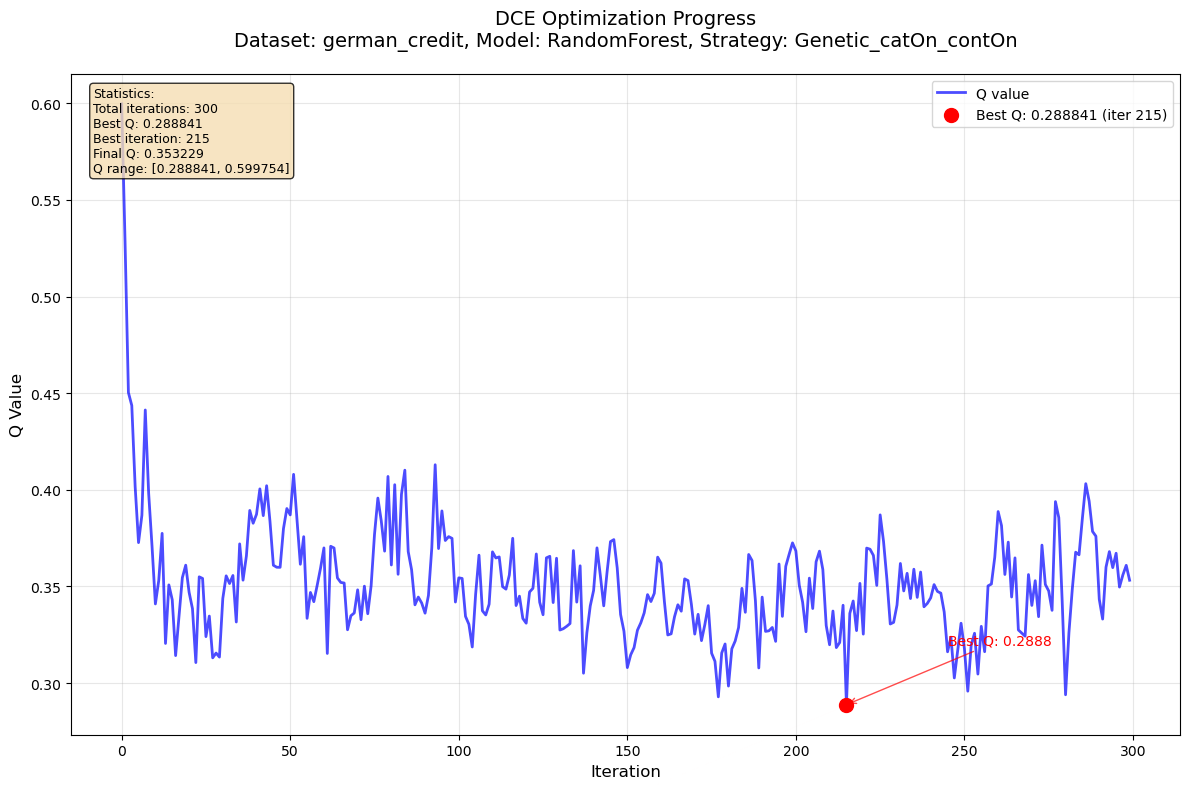

📈 Plot details:
   Total iterations: 300
   Best Q value: 0.288841 at iteration 215
   Final Q value: 0.353229
   Q improvement: 0.310912
🔍 Found Q plot files in current directory: ['best_Q_200.png', 'best_Q_300.png', 'best_Q_50.png']


In [21]:
# Visualization: Q value optimization progress
if 'results_directory' in locals() and results_directory:
    try:
        import matplotlib.pyplot as plt
        
        # Load optimization log
        optimization_log_path = os.path.join(results_directory, "optimization_log.csv")
        
        if os.path.exists(optimization_log_path):
            # Read the optimization log
            log_df = pd.read_csv(optimization_log_path)
            
            print("📊 Creating Q optimization progress visualization...")
            
            # Create the plot
            plt.figure(figsize=(12, 8))
            
            # Plot Q values over iterations
            plt.plot(log_df['iteration'], log_df['Q'], 'b-', linewidth=2, label='Q value', alpha=0.7)
            
            # Find and highlight the best Q value
            best_q_idx = log_df['Q'].idxmin()
            best_q_value = log_df.loc[best_q_idx, 'Q']
            best_iteration = log_df.loc[best_q_idx, 'iteration']
            
            plt.scatter(best_iteration, best_q_value, color='red', s=100, zorder=5, 
                       label=f'Best Q: {best_q_value:.6f} (iter {best_iteration})')
            
            # Highlight feasible solutions if available
            if 'is_feasible' in log_df.columns:
                feasible_points = log_df[log_df['is_feasible'] == True]
                if not feasible_points.empty:
                    plt.scatter(feasible_points['iteration'], feasible_points['Q'], 
                              color='green', s=50, alpha=0.6, label='Feasible solutions')
            
            # Formatting
            plt.xlabel('Iteration', fontsize=12)
            plt.ylabel('Q Value', fontsize=12)
            plt.title(f'DCE Optimization Progress\nDataset: {dataset_name}, Model: {model_name}, Strategy: {strategy_name}', 
                     fontsize=14, pad=20)
            plt.grid(True, alpha=0.3)
            plt.legend()
            
            # Add annotation for best point
            plt.annotate(f'Best Q: {best_q_value:.4f}', 
                        xy=(best_iteration, best_q_value), 
                        xytext=(best_iteration + len(log_df) * 0.1, best_q_value + (log_df['Q'].max() - log_df['Q'].min()) * 0.1),
                        arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                        fontsize=10, color='red')
            
            # Add text box with key statistics
            stats_text = f"""Statistics:
Total iterations: {len(log_df)}
Best Q: {best_q_value:.6f}
Best iteration: {best_iteration}
Final Q: {log_df['Q'].iloc[-1]:.6f}
Q range: [{log_df['Q'].min():.6f}, {log_df['Q'].max():.6f}]"""
            
            plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
                    verticalalignment='top', fontsize=9, 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            
            plt.tight_layout()
            
            # Prepare save paths
            max_iter = len(log_df)
            plot_filename = f"best_Q_{max_iter}.png"
            
            # Save to current working directory
            current_dir = os.getcwd()
            plot_path = os.path.join(current_dir, plot_filename)
            print(f"🗂️ Current working directory: {current_dir}")
            print(f"📁 Attempting to save plot to: {plot_path}")
            
            try:
                plt.savefig(plot_path, dpi=300, bbox_inches='tight')
                print(f"✅ Successfully saved to current directory: {plot_path}")
                
                # Verify file was created
                if os.path.exists(plot_path):
                    file_size = os.path.getsize(plot_path)
                    print(f"📄 File verified: {plot_filename} ({file_size} bytes)")
                else:
                    print(f"❌ File not found after saving: {plot_path}")
                    
            except Exception as save_error:
                print(f"❌ Error saving to current directory: {save_error}")
            
            # Save to results directory
            if results_directory and os.path.exists(results_directory):
                results_plot_path = os.path.join(results_directory, plot_filename)
                print(f"📁 Attempting to save to results directory: {results_plot_path}")
                
                try:
                    plt.savefig(results_plot_path, dpi=300, bbox_inches='tight')
                    print(f"✅ Successfully saved to results directory: {results_plot_path}")
                    
                    # Verify file was created
                    if os.path.exists(results_plot_path):
                        file_size = os.path.getsize(results_plot_path)
                        print(f"📄 File verified in results: {plot_filename} ({file_size} bytes)")
                    else:
                        print(f"❌ File not found in results directory: {results_plot_path}")
                        
                except Exception as save_error:
                    print(f"❌ Error saving to results directory: {save_error}")
            else:
                print(f"❌ Results directory not accessible: {results_directory}")
            
            # Show the plot
            plt.show()
            
            print(f"📈 Plot details:")
            print(f"   Total iterations: {len(log_df)}")
            print(f"   Best Q value: {best_q_value:.6f} at iteration {best_iteration}")
            print(f"   Final Q value: {log_df['Q'].iloc[-1]:.6f}")
            print(f"   Q improvement: {log_df['Q'].iloc[0] - best_q_value:.6f}")
            
            # List files in current directory to verify
            try:
                current_files = [f for f in os.listdir(current_dir) if f.startswith('best_Q_') and f.endswith('.png')]
                if current_files:
                    print(f"🔍 Found Q plot files in current directory: {current_files}")
                else:
                    print(f"🔍 No Q plot files found in current directory")
            except Exception as list_error:
                print(f"❌ Error listing current directory: {list_error}")
            
        else:
            print(f"❌ Optimization log not found: {optimization_log_path}")
            
    except Exception as e:
        print(f"❌ Error creating Q optimization plot: {e}")
        import traceback
        traceback.print_exc()
else:
    print("❌ Results directory not available for plotting")

📊 Creating OT Distance optimization progress visualization...
✅ OT Distance plot saved to current directory: e:\desktop\DCE\ot_distance_300.png
📄 File verified: ot_distance_300.png (423573 bytes)
✅ OT Distance plot saved to results directory: Results\german_credit\RandomForest\DCE_u1=0.5,u2=0.3,l=0.2,r=1.0,mi=300,tk=50,nt=10\cone_all_Genetic_cp=0.8,gsp=0.5,mpc=0.3,mpo=0.8,mns=0.1,cs=1.2,ct=0.1,temp=2.0\seed_42_20250821_181503\ot_distance_300.png
📄 File verified in results: ot_distance_300.png (423573 bytes)


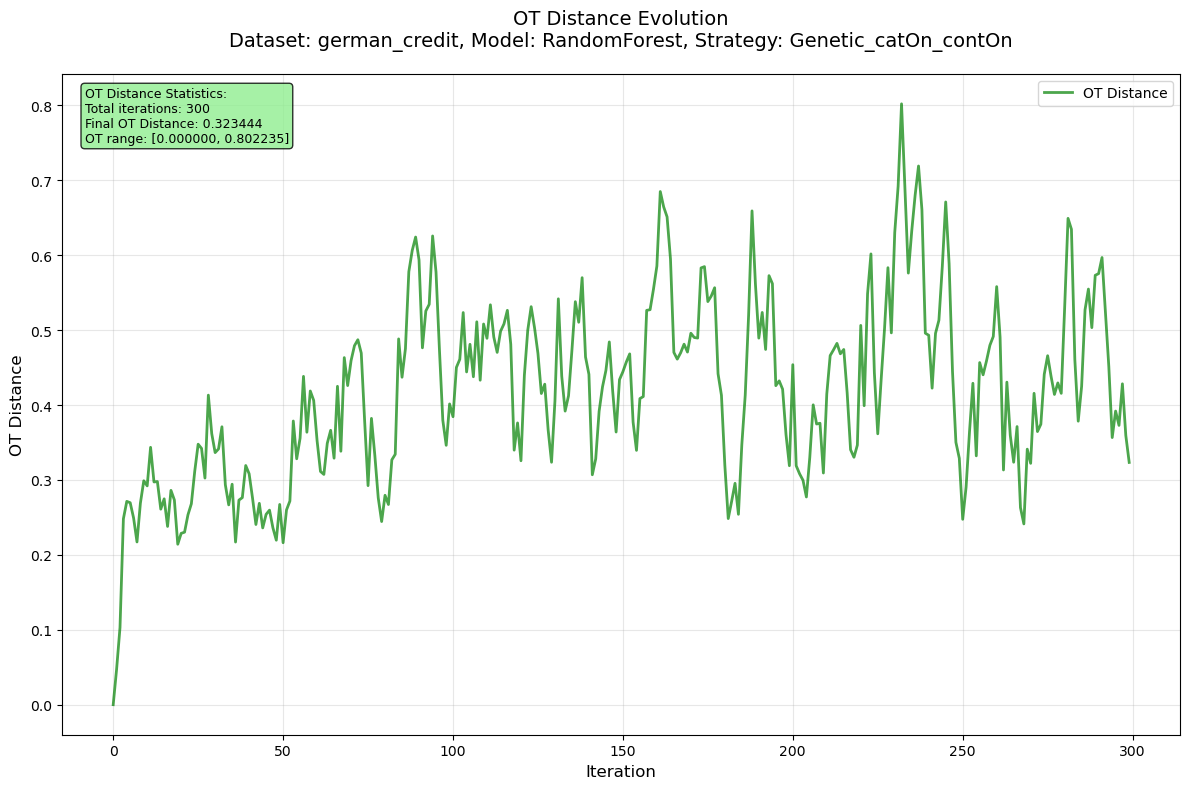

📈 OT Distance plot details:
   Total iterations: 300
   Final OT Distance: 0.323444
   OT Distance change: 0.323444


In [22]:
# Visualization: OT Distance optimization progress
if 'results_directory' in locals() and results_directory:
    try:
        import matplotlib.pyplot as plt
        
        # Load optimization log
        optimization_log_path = os.path.join(results_directory, "optimization_log.csv")
        
        if os.path.exists(optimization_log_path):
            # Read the optimization log
            log_df = pd.read_csv(optimization_log_path)
            
            # Check if OT distance data is available
            if 'OT_distance' in log_df.columns:
                print("📊 Creating OT Distance optimization progress visualization...")
                
                # Create the plot
                plt.figure(figsize=(12, 8))
                
                # Plot OT Distance values over iterations
                plt.plot(log_df['iteration'], log_df['OT_distance'], 'g-', linewidth=2, label='OT Distance', alpha=0.7)
                
                # Highlight feasible solutions if available
                if 'is_feasible' in log_df.columns:
                    feasible_points = log_df[log_df['is_feasible'] == True]
                    if not feasible_points.empty:
                        plt.scatter(feasible_points['iteration'], feasible_points['OT_distance'], 
                                  color='orange', s=50, alpha=0.6, label='Feasible solutions')
                
                # Formatting
                plt.xlabel('Iteration', fontsize=12)
                plt.ylabel('OT Distance', fontsize=12)
                plt.title(f'OT Distance Evolution\nDataset: {dataset_name}, Model: {model_name}, Strategy: {strategy_name}', 
                         fontsize=14, pad=20)
                plt.grid(True, alpha=0.3)
                plt.legend()
                
                # Add text box with key statistics
                stats_text = f"OT Distance Statistics:\nTotal iterations: {len(log_df)}\nFinal OT Distance: {log_df['OT_distance'].iloc[-1]:.6f}\nOT range: [{log_df['OT_distance'].min():.6f}, {log_df['OT_distance'].max():.6f}]"
                
                plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
                        verticalalignment='top', fontsize=9, 
                        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
                
                plt.tight_layout()
                
                # Prepare save paths
                max_iter = len(log_df)
                plot_filename = f"ot_distance_{max_iter}.png"
                
                # Save to current working directory
                current_dir = os.getcwd()
                plot_path = os.path.join(current_dir, plot_filename)
                
                try:
                    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
                    print(f"✅ OT Distance plot saved to current directory: {plot_path}")
                    
                    # Verify file was created
                    if os.path.exists(plot_path):
                        file_size = os.path.getsize(plot_path)
                        print(f"📄 File verified: {plot_filename} ({file_size} bytes)")
                    
                except Exception as save_error:
                    print(f"❌ Error saving OT Distance plot to current directory: {save_error}")
                
                # Save to results directory
                if results_directory and os.path.exists(results_directory):
                    results_plot_path = os.path.join(results_directory, plot_filename)
                    
                    try:
                        plt.savefig(results_plot_path, dpi=300, bbox_inches='tight')
                        print(f"✅ OT Distance plot saved to results directory: {results_plot_path}")
                        
                        # Verify file was created
                        if os.path.exists(results_plot_path):
                            file_size = os.path.getsize(results_plot_path)
                            print(f"📄 File verified in results: {plot_filename} ({file_size} bytes)")
                            
                    except Exception as save_error:
                        print(f"❌ Error saving OT Distance plot to results directory: {save_error}")
                
                # Show the plot
                plt.show()
                
                print(f"📈 OT Distance plot details:")
                print(f"   Total iterations: {len(log_df)}")
                print(f"   Final OT Distance: {log_df['OT_distance'].iloc[-1]:.6f}")
                if len(log_df) > 1:
                    print(f"   OT Distance change: {log_df['OT_distance'].iloc[-1] - log_df['OT_distance'].iloc[0]:.6f}")
                
            else:
                print("📊 OT Distance data not available in optimization log")
                print("   Note: OT Distance tracking requires callback='full' mode")
                
        else:
            print(f"❌ Optimization log not found: {optimization_log_path}")
            
    except Exception as e:
        print(f"❌ Error creating OT Distance optimization plot: {e}")
        import traceback
        traceback.print_exc()
else:
    print("❌ Results directory not available for OT Distance plotting")

In [23]:
# Final Metrics Summary
print("📈 Final Metrics Summary")
print("=" * 60)

if all_metrics:
    # Core metrics
    core_metrics = ['Coverage Rate', 'MMD', 'OT Distance', 'AReS Cost']
    
    print("🎯 Core Metrics:")
    for metric in core_metrics:
        if metric in all_metrics:
            value = all_metrics[metric]
            if isinstance(value, float) and not np.isnan(value):
                print(f"   {metric}: {value:.3f}")
            else:
                print(f"   {metric}: {value}")
    
    # Percentile differences
    percentile_metrics = [k for k in all_metrics.keys() if k.startswith('Percentile Difference')]
    if percentile_metrics:
        print(f"\n📊 Percentile Differences:")
        for metric in sorted(percentile_metrics):
            value = all_metrics[metric]
            if isinstance(value, float) and not np.isnan(value):
                print(f"   {metric}: {value:.3f}%")
            else:
                print(f"   {metric}: {value}")
    
    # # Additional metrics (excluding AReS Cost details since we now have single value)
    # other_metrics = [k for k in all_metrics.keys() 
    #                 if k not in core_metrics and not k.startswith('Percentile Difference')]
    # if other_metrics:
    #     print(f"\n📋 Additional Metrics:")
    #     for metric in sorted(other_metrics):
    #         value = all_metrics[metric]
    #         if isinstance(value, float) and not np.isnan(value):
    #             print(f"   {metric}: {value:.3f}")
    #         else:
    #             print(f"   {metric}: {value}")
    
    # print(f"\n✅ Total metrics calculated: {len(all_metrics)}")
    
    # Save metrics to file if results directory is available
    if 'results_directory' in locals() and results_directory:
        import json
        metrics_file = os.path.join(results_directory, "metrics_summary.json")
        try:
            # Convert any numpy types to Python types for JSON serialization
            metrics_for_json = {}
            for k, v in all_metrics.items():
                if isinstance(v, np.ndarray):
                    metrics_for_json[k] = v.tolist()
                elif isinstance(v, (np.integer, np.floating, np.bool_)):
                    metrics_for_json[k] = v.item()
                else:
                    metrics_for_json[k] = v
            
            with open(metrics_file, 'w') as f:
                json.dump(metrics_for_json, f, indent=2)
            print(f"\n💾 Metrics saved to: {metrics_file}")
        except Exception as e:
            print(f"\n❌ Error saving metrics: {e}")
    
else:
    print("❌ No metrics calculated")

print("=" * 60)

📈 Final Metrics Summary
🎯 Core Metrics:
   Coverage Rate: 0.000
   MMD: 0.000
   OT Distance: 0.000
   AReS Cost: 0.000

📊 Percentile Differences:
   Percentile Difference 0-15%: 0.000%
   Percentile Difference 15-30%: 0.000%
   Percentile Difference 30-70%: 0.000%
   Percentile Difference 70-85%: 0.000%
   Percentile Difference 85-100%: 0.000%

💾 Metrics saved to: Results\german_credit\RandomForest\DCE_u1=0.5,u2=0.3,l=0.2,r=1.0,mi=300,tk=50,nt=10\cone_all_Genetic_cp=0.8,gsp=0.5,mpc=0.3,mpo=0.8,mns=0.1,cs=1.2,ct=0.1,temp=2.0\seed_42_20250821_181503\metrics_summary.json


In [24]:
# Debug: Test OT distance calculation manually
print("🔍 Testing OT distance calculation manually...")

try:
    # Import required classes
    from explainers.distances import SlicedWassersteinDivergence, WassersteinDivergence
    import torch
    
    print("✅ Imports successful")
    
    # Create test data
    X_s = torch.randn(10, 5)  # 10 samples, 5 features
    X_t = torch.randn(10, 5)  # 10 samples, 5 features
    
    print(f"✅ Test data created: X_s shape {X_s.shape}, X_t shape {X_t.shape}")
    
    # Test computation function
    def compute_ot_distance(X_s, X_t):
        # Convert to proper tensor format
        if hasattr(X_s, 'values'):  # pandas DataFrame
            X_s_tensor = torch.FloatTensor(X_s.values)
        elif isinstance(X_s, np.ndarray):
            X_s_tensor = torch.FloatTensor(X_s)
        else:
            X_s_tensor = X_s
        
        if hasattr(X_t, 'values'):  # pandas DataFrame  
            X_t_tensor = torch.FloatTensor(X_t.values)
        elif isinstance(X_t, np.ndarray):
            X_t_tensor = torch.FloatTensor(X_t)
        else:
            X_t_tensor = X_t

        if X_s_tensor.ndim == 1:
            wd = WassersteinDivergence()
            distance, _ = wd.distance(X_s_tensor, X_t_tensor, delta=0.1)
        else:
            swd = SlicedWassersteinDivergence(dim=X_s_tensor.shape[1], n_proj=5000, random_state=42)
            distance, _ = swd.distance(X_s_tensor, X_t_tensor, delta=0.1)
        return distance.item()
    
    # Test the computation
    test_distance = compute_ot_distance(X_s, X_t)
    print(f"✅ OT distance calculation successful: {test_distance:.6f}")
    
    # Test with real data if available
    if 'counterfactual_X_df_standardized' in locals() and 'factual_X_df_standardized' in locals():
        real_distance = compute_ot_distance(counterfactual_X_df_standardized, factual_X_df_standardized)
        print(f"✅ Real data OT distance: {real_distance:.6f}")
    else:
        print("⚠️ Real data not available for testing")
        
except Exception as e:
    print(f"❌ OT distance calculation failed: {e}")
    import traceback
    traceback.print_exc()

🔍 Testing OT distance calculation manually...
✅ Imports successful
✅ Test data created: X_s shape torch.Size([10, 5]), X_t shape torch.Size([10, 5])
❌ OT distance calculation failed: new(): data must be a sequence (got builtin_function_or_method)


Traceback (most recent call last):
  File "C:\Users\Yikai Gu\AppData\Local\Temp\ipykernel_12016\3592136689.py", line 43, in <module>
    test_distance = compute_ot_distance(X_s, X_t)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Yikai Gu\AppData\Local\Temp\ipykernel_12016\3592136689.py", line 21, in compute_ot_distance
    X_s_tensor = torch.FloatTensor(X_s.values)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: new(): data must be a sequence (got builtin_function_or_method)
